In [1]:
import pandas as pd
import numpy as np  

In [2]:
df = pd.read_csv('nepse.csv')
df = df.sort_values(by='Date', ascending=True)
print(df.head())

     Symbol        Date     Open     High      Low    Close Percent Change  \
1156  NEPSE  2021-03-31  2596.66  2619.15  2592.80  2619.03         0.00 %   
1155  NEPSE  2021-04-01  2645.50  2645.50  2615.26  2631.90         0.00 %   
1154  NEPSE  2021-04-04  2658.31  2658.73  2646.05  2657.61         0.00 %   
1153  NEPSE  2021-04-05  2679.39  2682.27  2639.67  2658.75         0.00 %   
1152  NEPSE  2021-04-06  2678.96  2678.96  2641.80  2674.47         0.00 %   

                Volume Turn Over  
1156  6,166,900,815.53         -  
1155  7,250,924,123.60         -  
1154  9,006,858,557.96         -  
1153  7,296,760,155.82         -  
1152  7,477,795,737.92         -  


In [3]:
df['tp'] = (df['Close']+df['High']+df['Low'])/3

In [4]:
# Clean thousands separators before numeric conversion
df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',', '', regex=False), errors='coerce')
df['rmf'] = df['tp'] * df['Volume']

In [5]:
#Find postive and negative money flow
df['tp_diff'] = df['tp'].diff()fig_div.add_hline(y=70, line_dash="dash", line_color="gray", row=2)
fig_div.add_hline(y=30, line_dash="dash", line_color="gray", row=2)
df['Postive_tp']= df['tp_diff'] > 0
df['Negative_tp']= df['tp_diff'] < 0


In [6]:
df['pos_flow'] = df['rmf'].where(df['Postive_tp'], 0)
df['neg_flow'] = df['rmf'].where(df['Negative_tp'], 0)

pos_sum = df['pos_flow'].rolling(14).sum()
neg_sum = df['neg_flow'].rolling(14).sum()

mfr = pos_sum / neg_sum
df['mfi'] = 100 - (100 / (1 + mfr))

In [7]:
df.tail()

,Symbol,Date,Open,High,Low,Close,Percent Change,Volume,Turn Over,tp,rmf,tp_diff,Postive_tp,Negative_tp,pos_flow,neg_flow,mfi
4,NEPSE,2026-03-24,2943.47,2960.40,2928.34,2960.40,0.81 %,1.483918e+10,-,2949.713333,4.377134e+13,21.666667,True,False,4.377134e+13,0.000000e+00,71.565537
3,NEPSE,2026-03-25,2964.68,2969.50,2929.44,2935.94,-0.82 %,1.509042e+10,-,2944.960000,4.444067e+13,-4.753333,False,True,0.000000e+00,4.444067e+13,65.145780
2,NEPSE,2026-03-26,2933.89,2951.18,2918.36,2950.50,0.49 %,1.314851e+10,-,2940.013333,3.865680e+13,-4.946667,False,True,0.000000e+00,3.865680e+13,59.792265
1,NEPSE,2026-03-29,2958.78,2958.79,2872.99,2879.11,-2.40 %,1.503331e+10,-,2903.630000,4.365117e+13,-36.383333,False,True,0.000000e+00,4.365117e+13,54.269434
0,NEPSE,2026-03-30,2881.98,2891.53,2821.82,2831.39,-1.65 %,1.296666e+10,-,2848.246667,3.693224e+13,-55.383333,False,True,0.000000e+00,3.693224e+13,50.975415


In [8]:
# Prepare data for plotting: convert date to datetime
df_plot = df.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplots with 2 rows and shared x-axis
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    row_heights=[0.7, 0.3],
    subplot_titles=("Candlestick Chart", "Money Flow Index (MFI)")
)

# Convert date to string to use as categorical axis (preserves gaps)
df_plot['Date_str'] = df_plot['Date'].astype(str)

# Add candlestick chart to the first subplot
fig.add_trace(
    go.Candlestick(
        x=df_plot['Date_str'],
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close'],
        name='OHLC',
        increasing_line_color='green',
        decreasing_line_color='red',
    ),
    row=1, col=1
)

# Add MFI line chart to the second subplot
fig.add_trace(
    go.Scatter(
        x=df_plot['Date_str'],
        y=df_plot['mfi'],
        mode='lines',
        name='MFI',
        line=dict(color='blue', width=2),
        fill='tozeroy',
        fillcolor='rgba(0, 0, 255, 0.2)'
    ),
    row=2, col=1
)

# Add horizontal line at 70 and 30 for overbought/oversold
fig.add_hline(y=70, line_dash="dash", line_color="red", annotation_text="Overbought", row=2)
fig.add_hline(y=30, line_dash="dash", line_color="green", annotation_text="Oversold", row=2)

# Update layout
fig.update_layout(
    height=700,
    title_text="Trading View with MFI Indicator",
    xaxis_rangeslider_visible=False,
    hovermode='x unified',
    template='plotly_white'
)

# Update y-axes labels
fig.update_yaxes(title_text="Price", row=1, col=1)
fig.update_yaxes(title_text="MFI", row=2, col=1)

fig.show()

In [10]:
# Swing detection function
def find_swings(series, lookback=10):
    highs, lows = [], []
    for i in range(lookback, len(series) - lookback):
        window = series.iloc[i-lookback: lookback + i +1]
        current = float(series.iloc[i])
        if current == float(window.max()):
            highs.append(i)
        if current == float(window.min()):
            lows.append(i)
    return highs, lows

# Find swing highs and lows for price
high_idx, low_idx = find_swings(df_plot["Close"])

# Divergence detection
regular_bullish, regular_bearish = [], []
hidden_bullish, hidden_bearish = [], []

# Regular Bullish: Price LL, MFI HL
for i in range(1, len(low_idx)):
    p1, p2 = low_idx[i - 1], low_idx[i]
    if df_plot["Close"].iloc[p2] < df_plot["Close"].iloc[p1] and df_plot["mfi"].iloc[p2] > df_plot["mfi"].iloc[p1]:
        regular_bullish.append((p1, p2))

# Regular Bearish: Price HH, MFI LH
for i in range(1, len(high_idx)):
    p1, p2 = high_idx[i - 1], high_idx[i]
    if df_plot["Close"].iloc[p2] > df_plot["Close"].iloc[p1] and df_plot["mfi"].iloc[p2] < df_plot["mfi"].iloc[p1]:
        regular_bearish.append((p1, p2))

# Hidden Bullish: Price HL, MFI LL
for i in range(1, len(low_idx)):
    p1, p2 = low_idx[i-1], low_idx[i]
    if df_plot["Close"].iloc[p2] > df_plot["Close"].iloc[p1] and df_plot["mfi"].iloc[p2] < df_plot["mfi"].iloc[p1]:
        hidden_bullish.append((p1, p2))

# Hidden Bearish: Price LH, MFI HH
for i in range(1, len(high_idx)):
    p1, p2 = high_idx[i-1], high_idx[i]
    if df_plot["Close"].iloc[p2] < df_plot["Close"].iloc[p1] and df_plot["mfi"].iloc[p2] > df_plot["mfi"].iloc[p1]:
        hidden_bearish.append((p1, p2))

print("Regular Bullish Divergences:", regular_bullish)
print("Regular Bearish Divergences:", regular_bearish)
print("Hidden Bullish Divergences:", hidden_bullish)
print("Hidden Bearish Divergences:", hidden_bearish)

Regular Bullish Divergences: [(223, 293), (412, 481), (690, 729), (966, 993), (993, 1058)]
Regular Bearish Divergences: [(643, 658), (834, 847)]
Hidden Bullish Divergences: [(16, 67), (307, 335), (729, 765), (765, 824), (879, 933), (1074, 1099), (1099, 1135)]
Hidden Bearish Divergences: [(95, 142), (360, 385), (1036, 1064)]


Regular Bullish Divergences: 5
Regular Bearish Divergences: 2
Hidden Bullish Divergences: 7
Hidden Bearish Divergences: 3


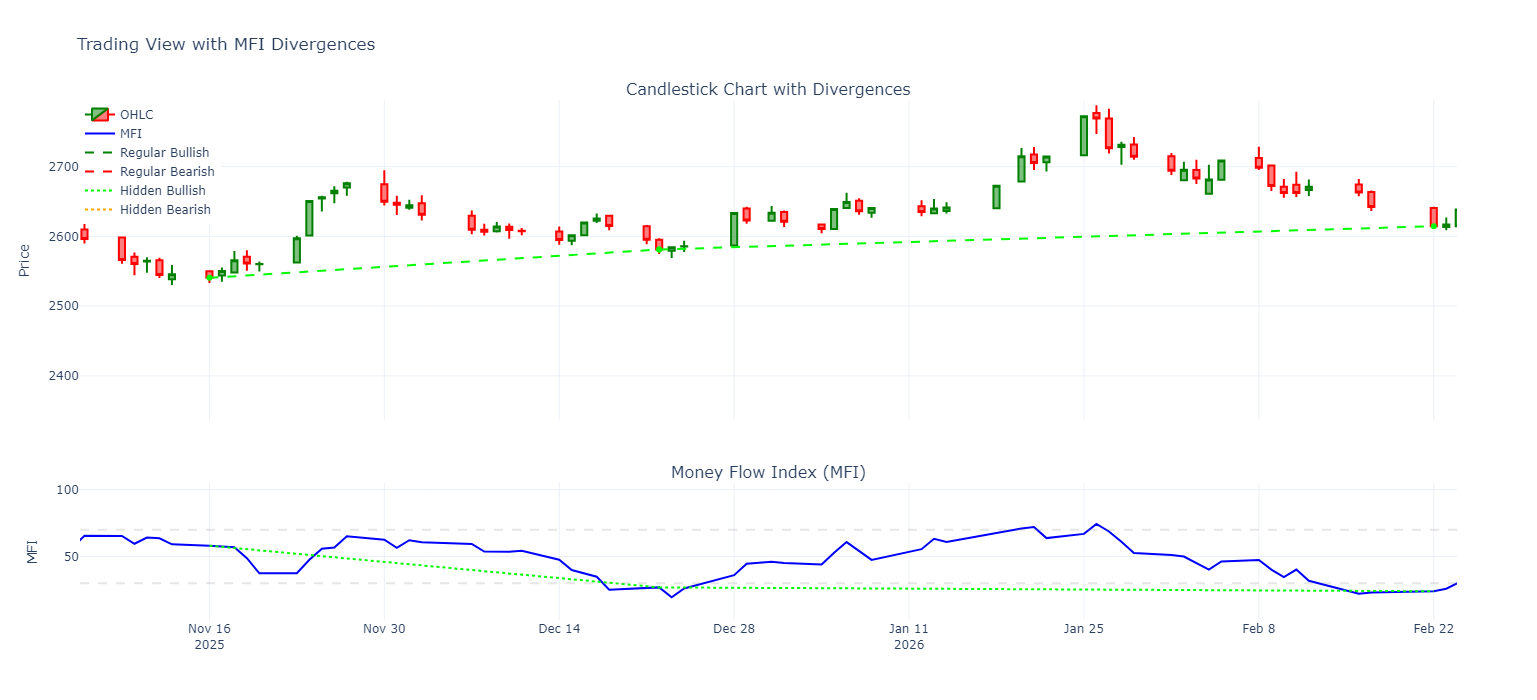

In [11]:
# Plot divergence lines on the chart
fig_div = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    row_heights=[0.7, 0.3],
    subplot_titles=("Candlestick Chart with Divergences", "Money Flow Index (MFI)")
)

# Add candlestick chart
fig_div.add_trace(
    go.Candlestick(
        x=df_plot['Date_str'],
        open=df_plot['Open'],
        high=df_plot['High'],
        low=df_plot['Low'],
        close=df_plot['Close'],
        name='OHLC',
        increasing_line_color='green',
        decreasing_line_color='red',
    ),
    row=1, col=1
)

# Add MFI
fig_div.add_trace(
    go.Scatter(
        x=df_plot['Date_str'],
        y=df_plot['mfi'],
        mode='lines',
        name='MFI',
        line=dict(color='blue', width=2)
      
    ),
    row=2, col=1
)

# Regular Bullish on PRICE
for p1, p2 in regular_bullish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['Close'].iloc[p1], df_plot['Close'].iloc[p2]],
            mode='lines+markers',
            line=dict(color='green', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Regular Bullish<extra></extra>'
        ),
        row=1, col=1
    )

# Regular Bearish on PRICE
for p1, p2 in regular_bearish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['Close'].iloc[p1], df_plot['Close'].iloc[p2]],
            mode='lines+markers',
            line=dict(color='red', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Regular Bearish<extra></extra>'
        ),
        row=1, col=1
    )

# Hidden Bullish on PRICE
for p1, p2 in hidden_bullish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['Close'].iloc[p1], df_plot['Close'].iloc[p2]],
            mode='lines+markers',
            line=dict(color='lime', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Hidden Bullish<extra></extra>'
        ),
        row=1, col=1
    )

# Hidden Bearish on PRICE
for p1, p2 in hidden_bearish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['Close'].iloc[p1], df_plot['Close'].iloc[p2]],
            mode='lines+markers',
            line=dict(color='orange', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Hidden Bearish<extra></extra>'
        ),
        row=1, col=1
    )

# Regular Bullish on MFI
for p1, p2 in regular_bullish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['mfi'].iloc[p1], df_plot['mfi'].iloc[p2]],
            mode='lines',
            line=dict(color='green', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Regular Bullish<extra></extra>'
        ),
        row=2, col=1
    )

# Regular Bearish on MFI
for p1, p2 in regular_bearish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['mfi'].iloc[p1], df_plot['mfi'].iloc[p2]],
            mode='lines',
            line=dict(color='red', dash='dash', width=2),
            showlegend=False,
            hovertemplate='Regular Bearish<extra></extra>'
        ),
        row=2, col=1
    )

# Hidden Bullish on MFI
for p1, p2 in hidden_bullish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['mfi'].iloc[p1], df_plot['mfi'].iloc[p2]],
            mode='lines',
            line=dict(color='lime', dash='dot', width=2),
            showlegend=False,
            hovertemplate='Hidden Bullish<extra></extra>'
        ),
        row=2, col=1
    )

# Hidden Bearish on MFI
for p1, p2 in hidden_bearish:
    fig_div.add_trace(
        go.Scatter(
            x=[df_plot['Date_str'].iloc[p1], df_plot['Date_str'].iloc[p2]],
            y=[df_plot['mfi'].iloc[p1], df_plot['mfi'].iloc[p2]],
            mode='lines',
            line=dict(color='orange', dash='dot', width=2),
            showlegend=False,
            hovertemplate='Hidden Bearish<extra></extra>'
        ),
        row=2, col=1
    )

# Add overbought/oversold lines (faded)
fig_div.add_hline(y=70, line_dash="dash", line_color="rgba(128, 128, 128, 0.2)", row=2)
fig_div.add_hline(y=30, line_dash="dash", line_color="rgba(128, 128, 128, 0.2)", row=2)

# Add legend entries manually
fig_div.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='green', dash='dash', width=2), 
                         name='Regular Bullish'), row=1, col=1)
fig_div.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='red', dash='dash', width=2), 
                         name='Regular Bearish'), row=1, col=1)
fig_div.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='lime', dash='dot', width=2), 
                         name='Hidden Bullish'), row=1, col=1)
fig_div.add_trace(go.Scatter(x=[None], y=[None], mode='lines', 
                         line=dict(color='orange', dash='dot', width=2), 
                         name='Hidden Bearish'), row=1, col=1)

# Update layout
fig_div.update_layout(
    height=700,
    width=1400,
    title_text="Trading View with MFI Divergences",
    xaxis_rangeslider_visible=False,
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0, y=1)
)

fig_div.update_yaxes(title_text="Price", row=1, col=1)
fig_div.update_yaxes(title_text="MFI", row=2, col=1)

# Print summary
print(f"Regular Bullish Divergences: {len(regular_bullish)}")
print(f"Regular Bearish Divergences: {len(regular_bearish)}")
print(f"Hidden Bullish Divergences: {len(hidden_bullish)}")
print(f"Hidden Bearish Divergences: {len(hidden_bearish)}")

fig_div.show()

In [70]:
y_r_bullish = [y for _, y in regular_bullish]
y_r_bearish = [y for _, y in regular_bearish]
y_h_bullish = [y for _, y in hidden_bullish]
y_h_bearish = [y for _, y in hidden_bearish]

In [72]:
candle_intervals= [5,10,20,40,60]
results=[]

In [73]:
all_data=[]
for index in y_r_bullish:
    all_data.append((index, "Regular Bullish"))
for index in y_r_bearish:
    all_data.append((index, "Regular Bearish"))
for index in y_h_bullish:
    all_data.append((index, "Hidden Bullish"))
for index in y_h_bearish:
    all_data.append((index, "Hidden Bearish"))
    

In [75]:
symbol= df["Symbol"][0]
symbol

'NEPSE'

In [78]:
for i,pattern in all_data:
    if i+max(candle_intervals)>= len(df):
        continue
    for j in candle_intervals:
        price_now = df["Close"].iloc[i]
        price_future = df["Close"].iloc[i+j]

        pc= (price_future-price_now)/price_now *100

        results.append({
            "Sector": symbol,
            "Pattern":pattern,
            "Interval":j,
            "Start Index":i,
            "EndIndex": i+j,
            "Price Now":price_now,
            "Price After Interval":price_future,
            "Percentage Change": pc
        })
        

In [79]:
results = pd.DataFrame(results)

In [80]:
results

,Sector,Pattern,Interval,Start Index,EndIndex,Price Now,Price After Interval,Percentage Change
0,NEPSE,Regular Bullish,5,293,298,1848.28,1962.71,6.191162
1,NEPSE,Regular Bullish,10,293,303,1848.28,2030.59,9.863765
2,NEPSE,Regular Bullish,20,293,313,1848.28,2029.43,9.801004
3,NEPSE,Regular Bullish,40,293,333,1848.28,2056.88,11.286169
4,NEPSE,Regular Bullish,60,293,353,1848.28,1973.01,6.748436
...,...,...,...,...,...,...,...,...
70,NEPSE,Hidden Bearish,5,1064,1069,2631.14,2566.09,-2.472312
71,NEPSE,Hidden Bearish,10,1064,1074,2631.14,2540.57,-3.442234
72,NEPSE,Hidden Bearish,20,1064,1084,2631.14,2649.52,0.698557
73,NEPSE,Hidden Bearish,40,1064,1104,2631.14,2633.76,0.099577


In [84]:
results.to_excel(f"{symbol}_MFI_Divergence.xlsx",index=False)